In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

# Задание пространства

Проанализируем двумерную целевую функцию (на практике это непосредственно функция от гиперпараметров того же XGBoost, например f(scale_pos_weight, max_depth) = ошибка модели).
$$
f(x, y) = f_{\text{rosenbrock}}(x, y)
$$

где:
- $f_{\text{rosenbrock}}(x, y)$ — функция Розенброка


Функция Розенброка:

$$
f_{\text{rosenbrock}}(x, y) = 30(y - x^2)^2 + (1 - x)^2
$$

Глобальный минимум (1, 1) = 0

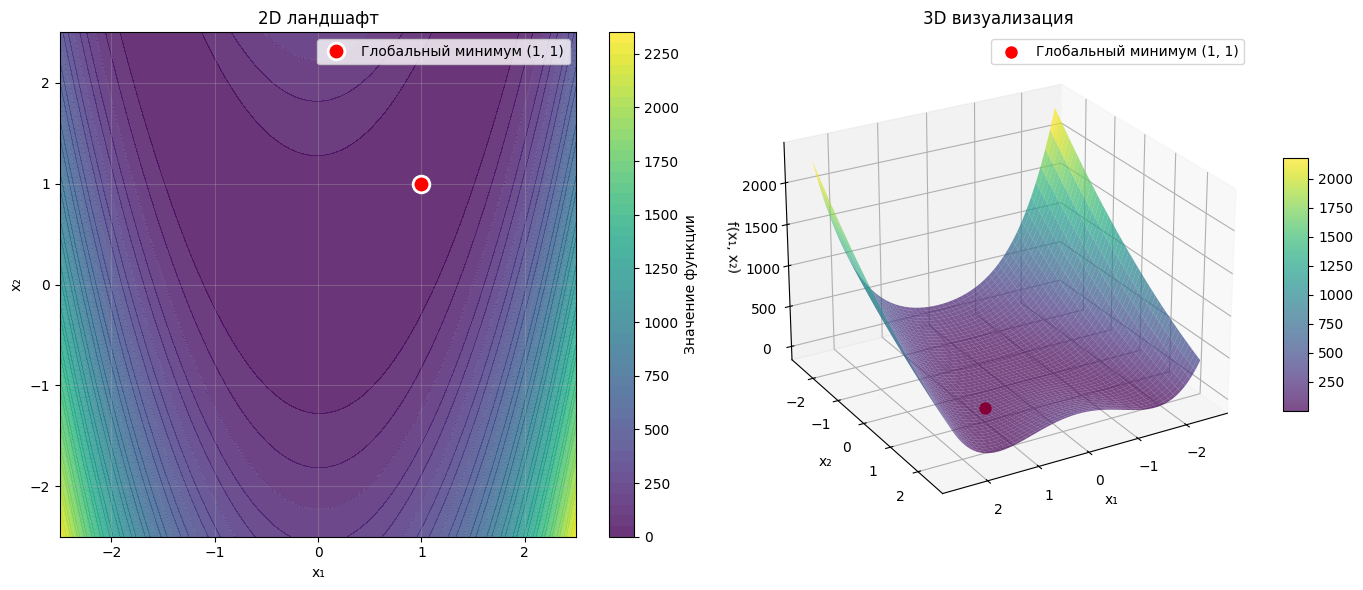

 Глобальный минимум в (1, 1): f = 0.0000


In [44]:
def objective_function(x, y):
    rosenbrock = 30 * (y - x**2)**2 + (1 - x)**2
    return rosenbrock

x_range = np.linspace(-2.5, 2.5, 200)
y_range = np.linspace(-2.5, 2.5, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = objective_function(X, Y)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Значение функции')
plt.contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.5)

plt.plot(1, 1, 'ro', markersize=12, label=f'Глобальный минимум (1, 1)',
         markeredgecolor='white', markeredgewidth=2)

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('2D ландшафт')
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.subplot(1, 2, 2, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7,
                       linewidth=0, antialiased=True)

ax.scatter(1, 1, objective_function(1, 1), color='red', s=100,
           label='Глобальный минимум (1, 1)', edgecolor='white')

ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_zlabel('f(x₁, x₂)')
ax.set_title('3D визуализация')
ax.legend()
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.view_init(elev=25, azim=60)

plt.tight_layout()
plt.show()

print(f" Глобальный минимум в (1, 1): f = {objective_function(1, 1):.4f}")

Задача CMA-ES: найти глобальный минимум, не застряв в локальном.  
В некоторой окрестности этой точки нам будет необходимо найти группу точек, которые будут наилучшим образом смещаться в сторону глобального, а не локального минимума.  
Назовем окрестность точки доверительным эллипсом - точки, которые будем находить, будут генерироваться из нормального распределения и бОльшая часть этих точек будет внутри этого эллипса.
Введем начальный шаг поиска sigma = 0.8 (будет влиять на радиус, в котором ищется следующая точка) и начальную ковариационную матрицу C как единичную (она будет задавать форму области поиска) - область поиска будет кругом:

In [45]:
sigma = 0.8 # начальный шаг поиска
dim = 2  # размерность пространства
C = np.eye(dim) # единичная ковариационная матрица
mean = np.array([0, -1]) # начальная точка и начальное среднее области

Начальная точка (центр): (0, -1)
Начальный шаг поиска σ: 0.8
Ковариационная матрица C (начальная):
[[1. 0.]
 [0. 1.]]


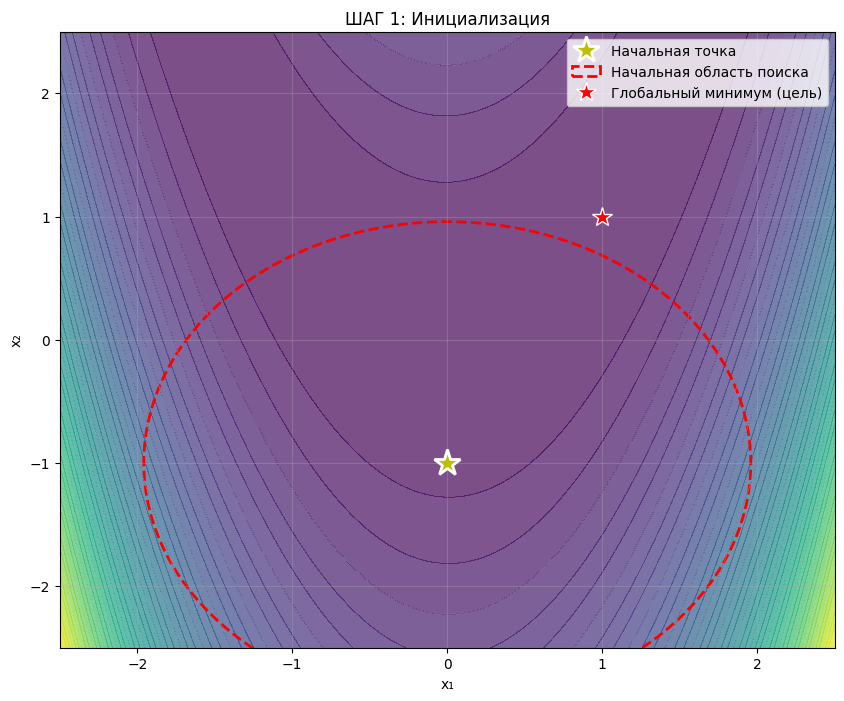

In [46]:
print(f"Начальная точка (центр): ({mean[0]}, {mean[1]})")
print(f"Начальный шаг поиска σ: {sigma}")
print(f"Ковариационная матрица C (начальная):")
print(C)

# Визуализация начального состояния
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
plt.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

# Рисуем начальную точку
plt.plot(mean[0], mean[1], 'y*', markersize=20, label='Начальная точка', markeredgecolor='white', markeredgewidth=2)

# Рисуем 95% доверительный круг (sigma * sqrt(5.991) для 95% в 2D)
circle = plt.Circle(mean, sigma * np.sqrt(5.991), fill=False, color='red', linewidth=2, linestyle='--', label='Начальная область поиска')
plt.gca().add_patch(circle)

plt.plot(1, 1, 'r*', markersize=15, label='Глобальный минимум (цель)', markeredgecolor='white', markeredgewidth=1)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('ШАГ 1: Инициализация')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.show()

Мы встали в начальную точку и приготовились искать. Область поиска - круг радиусом σ·√5.991 ≈ 0.8·2.45 ≈ 1.96,
внутри которого с вероятностью 95% окажутся сгенерированные точки.
Ковариационная матрица = I означает, что сначала мы ищем одинаково во всех направлениях (круг, а не эллипс).

# Сэмплирование (глава 1)

Этап сэмплирования находится в генерации потенциально "хороших" точек - тех, кто больше всего устремит нас в точку глобального экстремума. Сначала возьмем рандомные 15 точек (по формуле ниже). Мы уже выделили доверительный интервал, внутри которого с 95-процентной вероятностью будут находится эти точки.

### Формула сэмплирования в CMA-ES

На каждой итерации \(g\) новые точки генерируются следующим образом:

$$
\mathbf{x}_{k}^{(g+1)} \sim \mathbf{m}^{(g)} + \sigma^{(g)} \mathcal{N}\left(\mathbf{0}, \mathbf{C}^{(g)}\right), \quad \text{для } k = 1, \ldots, \lambda,\tag{5}
$$

где:  
$\mathbf{x}_{k}^{(g+1)}$ - $k$-й кандидат в поколении $g+1$  
$\mathbf{m}^{(g)}$ - текущее среднее (центр поиска)  (наш центр окружности)  
$\sigma^{(g)}$ - текущая длина шага (0.8)  
$\mathcal{N}(\mathbf{0}, \mathbf{C}^{(g)})$ - нормальное распределение (у нас двумерное)  
$\lambda$ — размер выборки (возьмем 15)

Сгенерировано 15 точек из распределения N(mean, σ²·C)
  mean = [0.00, -1.00]
  σ²·C = 0.6400000000000001 * I = 
 [[0.64 0.  ]
 [0.   0.64]]

Сгенерированные точки:
  Точка  1: ( 0.321, -0.612)
  Точка  2: (-0.045, -0.829)
  Точка  3: (-0.705, -1.166)
  Точка  4: ( 0.323, -1.863)
  Точка  5: (-0.208,  0.248)
  Точка  6: (-0.667, -1.527)
  Точка  7: ( 0.466,  0.400)
  Точка  8: (-0.972, -1.068)
  Точка  9: (-0.387, -2.293)
  Точка 10: ( 0.602,  0.012)
  Точка 11: (-0.505, -0.666)
  Точка 12: ( 0.906, -2.304)
  Точка 13: (-0.978, -0.309)
  Точка 14: ( 0.354, -0.903)
  Точка 15: ( 1.293, -2.067)


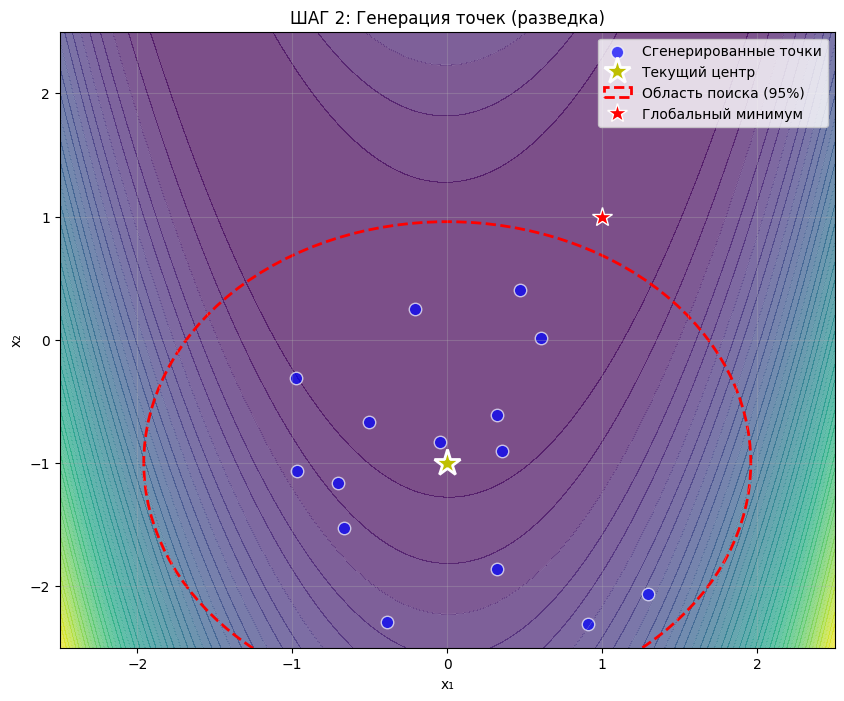

In [47]:
# размер выборки (сколько точек генерируем на каждой итерации)
popsize = 15

# генерируем точки по формуле
points = np.random.multivariate_normal(mean, sigma**2 * C, size=popsize) #применяем свойство линейных преобразований НР (а так это формула выше)
print(f"Сгенерировано {popsize} точек из распределения N(mean, σ²·C)")
print(f"  mean = [{mean[0]:.2f}, {mean[1]:.2f}]")
print(f"  σ²·C = {sigma**2} * I = \n {sigma**2*C}")
print("\nСгенерированные точки:")
for i, point in enumerate(points):
    print(f"  Точка {i+1:2d}: ({point[0]:6.3f}, {point[1]:6.3f})")

plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
plt.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

plt.scatter(points[:, 0], points[:, 1], c='blue', s=80, alpha=0.7, label='Сгенерированные точки', edgecolors='white')

plt.plot(mean[0], mean[1], 'y*', markersize=20, label='Текущий центр', markeredgecolor='white', markeredgewidth=2)

circle = plt.Circle(mean, sigma * np.sqrt(5.991), fill=False, color='red', linewidth=2, linestyle='--', label='Область поиска (95%)')
plt.gca().add_patch(circle)

plt.plot(1, 1, 'r*', markersize=15, label='Глобальный минимум', markeredgecolor='white', markeredgewidth=1)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('ШАГ 2: Генерация точек (разведка)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.show()

Таким образом, мы отправили точки в разные стороны. Они распределены нормально: большинство рядом с центром, чем дальше, тем меньше вероятность. Пока область поиска круглая, потому что ковариационная матрица C = I.

# Оценка и выбор лучших точек

Из 15 сгенерированных необходимо выбрать 7 лучших точек и рассмотреть их положение в пространстве гиперпараметров - сначала необходимо вычислить их вес в этом пространстве

$$w_i = \frac{\ln\left(\frac{\lambda + 1}{2}\right) - \ln(i)}{\sum_{j=1}^{\mu} \left( \ln\left(\frac{\lambda + 1}{2}\right) - \ln(j) \right)}, \quad i = 1, \ldots, 7$$


In [48]:
weights = np.log((popsize+0.5)/2) - np.log(np.arange(1, 7 + 1))
weights = weights / np.sum(weights)

Но что такое ЛУЧШИЕ точки? Интуитивно понятно, что лучшие точки - те, в которой целевая функция f(x) будет минимальна (т.к. стремимся к глобальному минимуму). Просто вызываем нашу целевую функцию (например, ошибку модели) для каждой сгенерированной точки и смотрим, где результат лучше:

Оценка всех точек:
   Точка  7: ( 0.466,  0.400) - значение функции:   1.2781 [Лучшая]
   Точка  5: (-0.208,  0.248) - значение функции:   2.7149 [Лучшая]
   Точка 10: ( 0.602,  0.012) - значение функции:   3.8395 [Лучшая]
   Точка  1: ( 0.321, -0.612) - значение функции:  15.7868 [Лучшая]
   Точка  2: (-0.045, -0.829) - значение функции:  21.8101 [Лучшая]
   Точка 11: (-0.505, -0.666) - значение функции:  27.6805 [Лучшая]
   Точка 14: ( 0.354, -0.903) - значение функции:  32.1663 [Лучшая]
   Точка 13: (-0.978, -0.309) - значение функции:  51.9471 [Плохая]
   Точка  3: (-0.705, -1.166) - значение функции:  85.8591 [Плохая]
   Точка  4: ( 0.323, -1.863) - значение функции: 116.5478 [Плохая]
   Точка  6: (-0.667, -1.527) - значение функции: 119.5290 [Плохая]
   Точка  8: (-0.972, -1.068) - значение функции: 125.4760 [Плохая]
   Точка  9: (-0.387, -2.293) - значение функции: 180.8319 [Плохая]
   Точка 12: ( 0.906, -2.304) - значение функции: 293.0189 [Плохая]
   Точка 15: ( 1.293, -2.067)

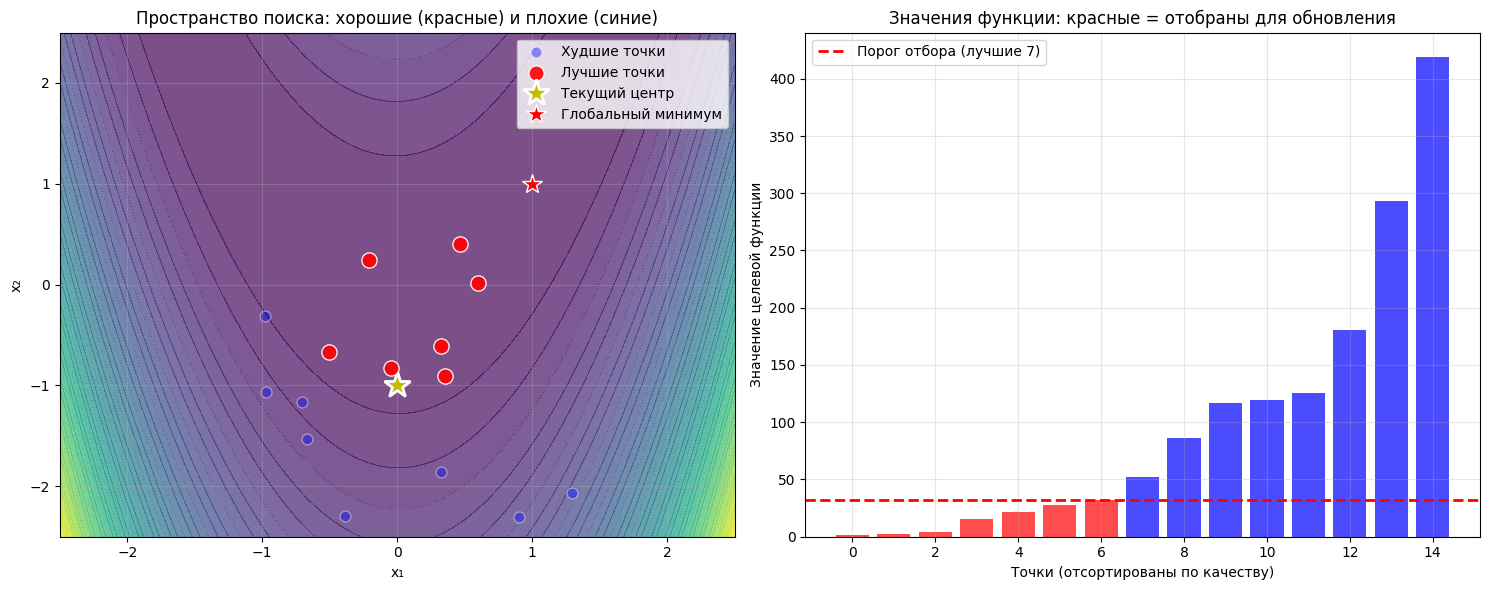

In [49]:
# Вычислим значения целевой функции для всех точек
fitness = np.array([objective_function(p[0], p[1]) for p in points])

# Сортируем по качеству (чем меньше значение функции - тем лучше)
sorted_indices = np.argsort(fitness)
best_indices = sorted_indices[:7]
best_points = points[best_indices]
best_fitness = fitness[best_indices]

# худшие точки (только для визуализации)
worst_indices = sorted_indices[7:]

print("Оценка всех точек:")
for i, idx in enumerate(sorted_indices):
    marker = "" if i < 7 else ""
    quality = "Лучшая" if i < 7 else "Плохая"
    print(f"  {marker} Точка {idx+1:2d}: ({points[idx, 0]:6.3f}, {points[idx, 1]:6.3f}) - значение функции: {fitness[idx]:8.4f} [{quality}]")

print(f"\nОтобрано {7} лучших точек для обновления:")
for i, (point, fit) in enumerate(zip(best_points, best_fitness)):
    print(f"  Лучшая {i+1}: ({point[0]:6.3f}, {point[1]:6.3f})\n значение функции: {fit:8.4f} (вес = {weights[i]:.3f})")
    print("_"*50)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
ax1.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

ax1.scatter(points[worst_indices, 0], points[worst_indices, 1],
            c='blue', s=60, alpha=0.4, label='Худшие точки', edgecolors='white')

ax1.scatter(best_points[:, 0], best_points[:, 1],
            c='red', s=120, alpha=0.9, label='Лучшие точки', edgecolors='white', zorder=5)

ax1.plot(mean[0], mean[1], 'y*', markersize=20, label='Текущий центр', markeredgecolor='white', markeredgewidth=2)

ax1.plot(1, 1, 'r*', markersize=15, label='Глобальный минимум', markeredgecolor='white', markeredgewidth=1)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title('Пространство поиска: хорошие (красные) и плохие (синие)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2.5, 2.5)
ax1.set_ylim(-2.5, 2.5)

# правый график(значения функции)
x_pos = np.arange(len(fitness))
sorted_fitness = fitness[sorted_indices]
bar_colors = []
for i in range(len(sorted_fitness)):
    if i < 7:
        bar_colors.append('red')
    else:
        bar_colors.append('blue')

bars = ax2.bar(x_pos, sorted_fitness, color=bar_colors, alpha=0.7)
ax2.axhline(y=fitness[best_indices[-1]], color='red', linestyle='--', linewidth=2,
            label=f'Порог отбора (лучшие {7})')
ax2.set_xlabel('Точки (отсортированы по качеству)')
ax2.set_ylabel('Значение целевой функции')
ax2.set_title('Значения функции: красные = отобраны для обновления')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Таким образом, мы оценили, кто из первично сгенерированных 15 точек нашел самые
   "глубокие" места. Лучшие (красные) точки будут использованы,
   чтобы решить, куда двигаться дальше.

Теперь обновим среднее (новый центр лучших точек) - новое среднее распределения поиска - это взвешенное среднее отобранных красных точек из выборки (веса уже были вычислены на предыдущем шаге)

Старый центр: (0.0000, -1.0000)

Вклад лучших точек в новый центр:
  Точка 1: ( 0.466,  0.400) × вес 0.353 -> вклад ( 0.164,  0.141)
  Точка 2: (-0.208,  0.248) × вес 0.233 -> вклад (-0.048,  0.058)
  Точка 3: ( 0.602,  0.012) × вес 0.163 -> вклад ( 0.098,  0.002)
  Точка 4: ( 0.321, -0.612) × вес 0.114 -> вклад ( 0.037, -0.070)
  Точка 5: (-0.045, -0.829) × вес 0.075 -> вклад (-0.003, -0.063)
  Точка 6: (-0.505, -0.666) × вес 0.044 -> вклад (-0.022, -0.029)
  Точка 7: ( 0.354, -0.903) × вес 0.018 -> вклад ( 0.006, -0.016)

Новый центр = сумма вкладов: (0.2315, 0.0232)
Вектор смещения: (0.2315, 1.0232)


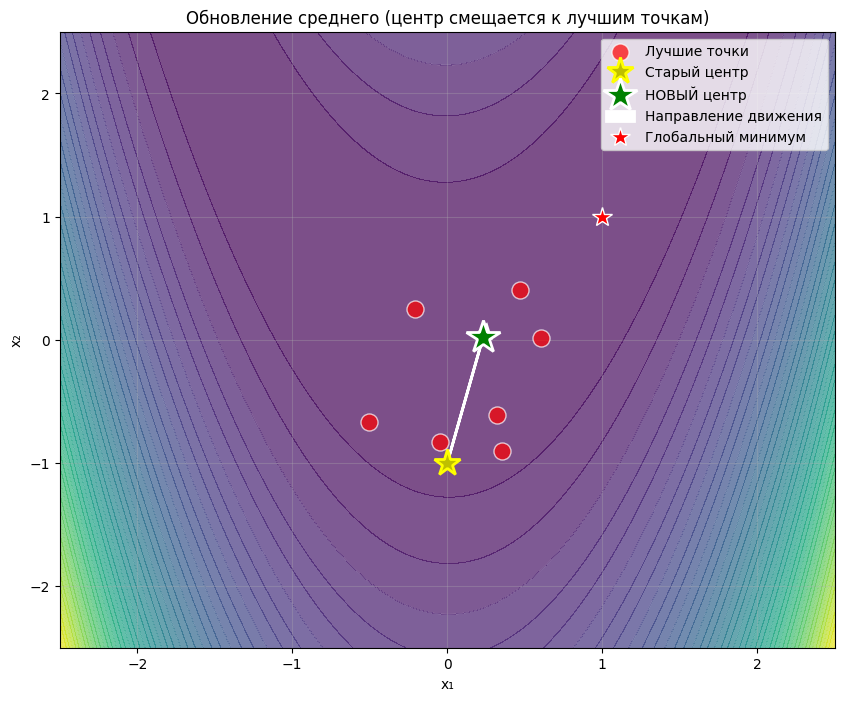

In [50]:
old_mean = mean.copy()
mean_new = np.sum(weights.reshape(-1, 1) * best_points, axis=0) # вес каждой точки умножаем на ее координаты в пространстве


print(f"Старый центр: ({old_mean[0]:.4f}, {old_mean[1]:.4f})")
print("\nВклад лучших точек в новый центр:")
for i, (point, weight) in enumerate(zip(best_points, weights)):
    contribution = point * weight
    print(f"  Точка {i+1}: ({point[0]:6.3f}, {point[1]:6.3f}) × вес {weight:.3f} -> вклад ({contribution[0]:6.3f}, {contribution[1]:6.3f})")

print(f"\nНовый центр = сумма вкладов: ({mean_new[0]:.4f}, {mean_new[1]:.4f})")
print(f"Вектор смещения: ({mean_new[0]-old_mean[0]:.4f}, {mean_new[1]-old_mean[1]:.4f})")

plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
plt.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

plt.scatter(best_points[:, 0], best_points[:, 1], c='red', s=150, alpha=0.7,
            label='Лучшие точки', edgecolors='white', zorder=5)

plt.plot(old_mean[0], old_mean[1], 'y*', markersize=20, label='Старый центр', markeredgecolor='yellow', markeredgewidth=2)

plt.plot(mean_new[0], mean_new[1], 'g*', markersize=25, label='НОВЫЙ центр', markeredgecolor='white', markeredgewidth=2)

# вектор смещения
plt.arrow(old_mean[0], old_mean[1],
          mean_new[0]-old_mean[0], mean_new[1]-old_mean[1],
          head_width=0.1, head_length=0.1, fc='white', ec='white', linewidth=2, label='Направление движения')

plt.plot(1, 1, 'r*', markersize=15, label='Глобальный минимум', markeredgecolor='white', markeredgewidth=1)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Обновление среднего (центр смещается к лучшим точкам)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.show()

In [51]:
#обновляем среднее для следующих шагов
mean = mean_new

Таким образом, двигаем центр в сторону лучших точек.
   Чем лучше точка, тем больше её вес. Это похоже на
   градиент - идём туда, где функция лучше.

# Адаптация ковариационной матрицы и глобального шага

Вспомним, что на первых шагах мы проинициализировали sigma = 0.8 как радиус окружности поиска новых точек и единичную ковариационную матрицу, построив таким образом окружность. Теперь, когда мы получили новый центр, необходимо понять новую "дальность" и форму поиска соотствественно.  

#### Ковариация

Для начала произведем адаптацию ковариационной матрицы по формуле:

$$ \mathbf{C}^{(g+1)} = (1 - c_{\mu}) \mathbf{C}^{(g)} + c_{\mu} \mathbf{C}_{\mu}^{(g+1)} $$

где
$$ \mathbf{C}_{\mu}^{(g+1)} = \sum_{i=1}^{\mu} w_i \mathbf{y}_{i:\lambda}^{(g+1)} \left(\mathbf{y}_{i:\lambda}^{(g+1)}\right)^{\mathrm{T}} $$

где:
- $\mathbf{C}^{(g+1)}$ — обновленная ковариационная матрица
- $\mathbf{C}^{(g)}$ — текущая ковариационная матрица
- $c_{\mu}$ — learning rate для rank-μ update ($0 < c_{\mu} \leq 1$) (возьмем 0.9)  
- $\mathbf{y}_{i:\lambda}^{(g+1)} = (\mathbf{x}_{i:\lambda}^{(g+1)} - \mathbf{m}^{(g)}) / \sigma^{(g)}$ — нормализованные шаги лучших точек
- $w_i$ — веса точек с прошлого шага ($\sum w_i = 1$)
- $\mu$ — количество лучших точек

In [52]:
y_k = (best_points - old_mean) / sigma # нормализованные шаги лучших точек

#вычисляем ковариацию лучших точек с весами
C_mu = np.sum(weights.reshape(-1, 1, 1) * (y_k.reshape(-1, dim, 1) @ y_k.reshape(-1, 1, dim)), axis=0)

c_mu = 0.9 # скорость обучения для ковариационной матрицы

C_new = (1 - c_mu) * C + c_mu * C_mu

print("Старая ковариационная матрица C:")
print(C)
print("\nКовариация лучших точек (с весами):")
print(C_mu)
print("\nНовая ковариационная матрица C_new:")
print(C_new)

Старая ковариационная матрица C:
[[1. 0.]
 [0. 1.]]

Ковариация лучших точек (с весами):
[[0.26759618 0.431231  ]
 [0.431231   1.94587392]]

Новая ковариационная матрица C_new:
[[0.34083656 0.3881079 ]
 [0.3881079  1.85128653]]



Собственные значения (размеры эллипса): [0.24694876 1.94517433]
Соотношение осей: 2.807 (1 = круг, <1 = вытянутый эллипс)


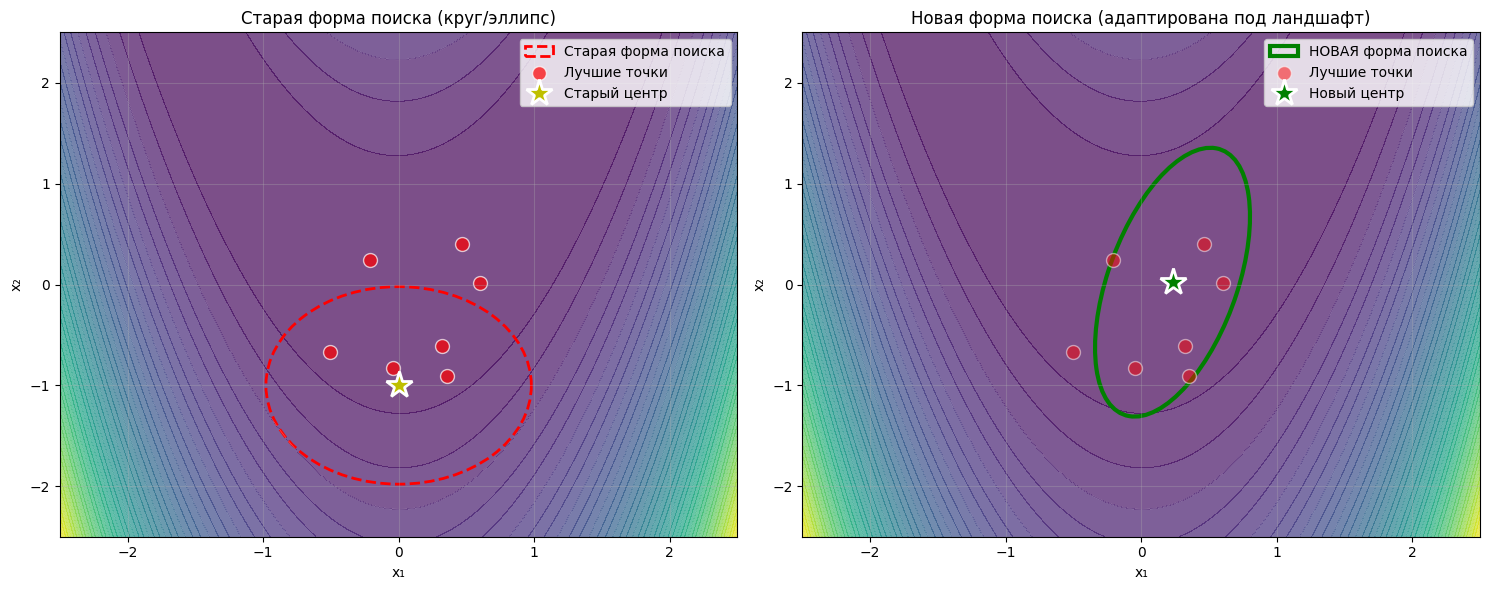

In [53]:
#вычисляем собственные значения и векторы(для понимания формы новой области - нашего эллипса)
eigvals, eigvecs = np.linalg.eigh(C_new)
print(f"\nСобственные значения (размеры эллипса): {eigvals}")
print(f"Соотношение осей: {np.sqrt(eigvals[1]/eigvals[0]):.3f} (1 = круг, <1 = вытянутый эллипс)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#левый график(старая ковариация)
ax1.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
ax1.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

#рисуем старый эллипс
eigvals_old, eigvecs_old = np.linalg.eigh(C)
idx_old = np.argsort(eigvals_old)[::-1]
angle_old = np.degrees(np.arctan2(eigvecs_old[1, idx_old[0]], eigvecs_old[0, idx_old[0]]))
ellipse_old = Ellipse(xy=old_mean,
                      width=sigma * np.sqrt(5.991 * eigvals_old[idx_old[0]]),
                      height=sigma * np.sqrt(5.991 * eigvals_old[idx_old[1]]),
                      angle=angle_old,
                      edgecolor='red', facecolor='none', linewidth=2, linestyle='--', label='Старая форма поиска')
ax1.add_patch(ellipse_old)

ax1.scatter(best_points[:, 0], best_points[:, 1], c='red', s=100, alpha=0.7, label='Лучшие точки', edgecolors='white')

ax1.plot(old_mean[0], old_mean[1], 'y*', markersize=20, label='Старый центр', markeredgecolor='white', markeredgewidth=2)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title('Старая форма поиска (круг/эллипс)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2.5, 2.5)
ax1.set_ylim(-2.5, 2.5)

#правый график(новая ковариация)
ax2.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
ax2.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

# рисуем новый эллипс
idx_new = np.argsort(eigvals)[::-1]
angle_new = np.degrees(np.arctan2(eigvecs[1, idx_new[0]], eigvecs[0, idx_new[0]]))
ellipse_new = Ellipse(xy=mean,
                      width=sigma * np.sqrt(5.991 * eigvals[idx_new[0]]),
                      height=sigma * np.sqrt(5.991 * eigvals[idx_new[1]]),
                      angle=angle_new,
                      edgecolor='green', facecolor='none', linewidth=3, linestyle='-', label='НОВАЯ форма поиска')
ax2.add_patch(ellipse_new)


ax2.scatter(best_points[:, 0], best_points[:, 1], c='red', s=100, alpha=0.5, label='Лучшие точки', edgecolors='white')

ax2.plot(mean[0], mean[1], 'g*', markersize=20, label='Новый центр', markeredgecolor='white', markeredgewidth=2)
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Новая форма поиска (адаптирована под ландшафт)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()

In [54]:
C = C_new # обновляем C

Таким образом мы меняем форму поиска. Если лучшие точки вытянуты в каком-то направлении, эллипс вытягивается в том же направлении. Это позволяет быстрее двигаться вдоль 'оврагов' функции.

#### "Дальность поиска" (sigma)

**Формула обновления шага** (из Hansen, 2016, Eq. 37, стр. 22):

$$
\sigma^{(g+1)} = \sigma^{(g)} \exp\left(\frac{c_{\sigma}}{d_{\sigma}}\left(\frac{\|\mathbf{p}_{\sigma}^{(g+1)}\|}{\mathbb{E}\|\mathcal{N}(\mathbf{0},\mathbf{I})\|} - 1\right)\right)
$$

где:
- $\mathbf{p}_{\sigma}^{(g+1)}$ — эволюционный путь (cumulative step-size adaptation path)
- $\mathbb{E}\|\mathcal{N}(\mathbf{0},\mathbf{I})\|$ — ожидаемая длина вектора из стандартного нормального распределения (см. ниже)
- $c_{\sigma}$ — скорость обучения (learning rate)
- $d_{\sigma}$ — демпфирующий параметр (подробнее с формулой параметра можно ознакомиться на стр. 31, однако, чтобы не загромождать код и показать суть метода, в коде зададим просто числовое значение)


***Разберем подробнее, что означает каждый из этих параметров***

Эта формула довольно обьемная и, так как целью является понять принцип работы и неглубоко копаться в мат. части, важно понять принцип каждого из параметров, а также как он влияет на итоговую величину sigma.

$\mathbf{p}_{\sigma}^{(g+1)}$ (эволюционный путь). Это вектор в пространстве поиска, который накапливает информацию о том, в каком направлении двигался центр распределения (среднее) на протяжении последних итераций.  
  
$\mathbb{E}\|\mathcal{N}(\mathbf{0},\mathbf{I})\|$ (ожидаемая длина вектора из стандартного нормального распределения) - эталонная длина. Если бы центр распределения двигался совершенно случайно (без всякого влияния отбора точек), то средняя длина его пути стремилась бы именно к этому значению. Это то, что мы бы наблюдали при отсутствии направленного движения.  

$c_{\sigma}$ (скорость обучения). Это коэффициент скорости обучения, который определяет, как быстро алгоритм учитывает новую информацию при обновлении направления поиска. Его можно интерпретировать как “длину памяти” алгоритма:
* маленькое значение означает, что алгоритм сильно усредняет прошлые шаги и ведёт себя более стабильно
* большое значение — что он быстрее реагирует на новые изменения, но может быть менее устойчивым


$d_{\sigma}$ (демпфирующий параметр). Позволяет настраивать, насколько активно
алгоритм будет менять глобальный масштаб поиска при обнаружении
устойчивого тренда в направлении или его отсутствии. Слишком малое $d_{\sigma}$ приводит к колебаниям и нестабильности (шаг начинает то резко возрастать, то падать, не успевая найти равновесие), слишком большое — к замедленной
реакции на изменение ландшафта функции.

Старый шаг σ: 0.8000
Норма смещения в преобразованном пространстве: 0.9410
Ожидаемая норма для случайного шага: 1.2543
Сравнение: step_norm < expected_norm
Уменьшаем шаг
Новый шаг σ: 0.7422


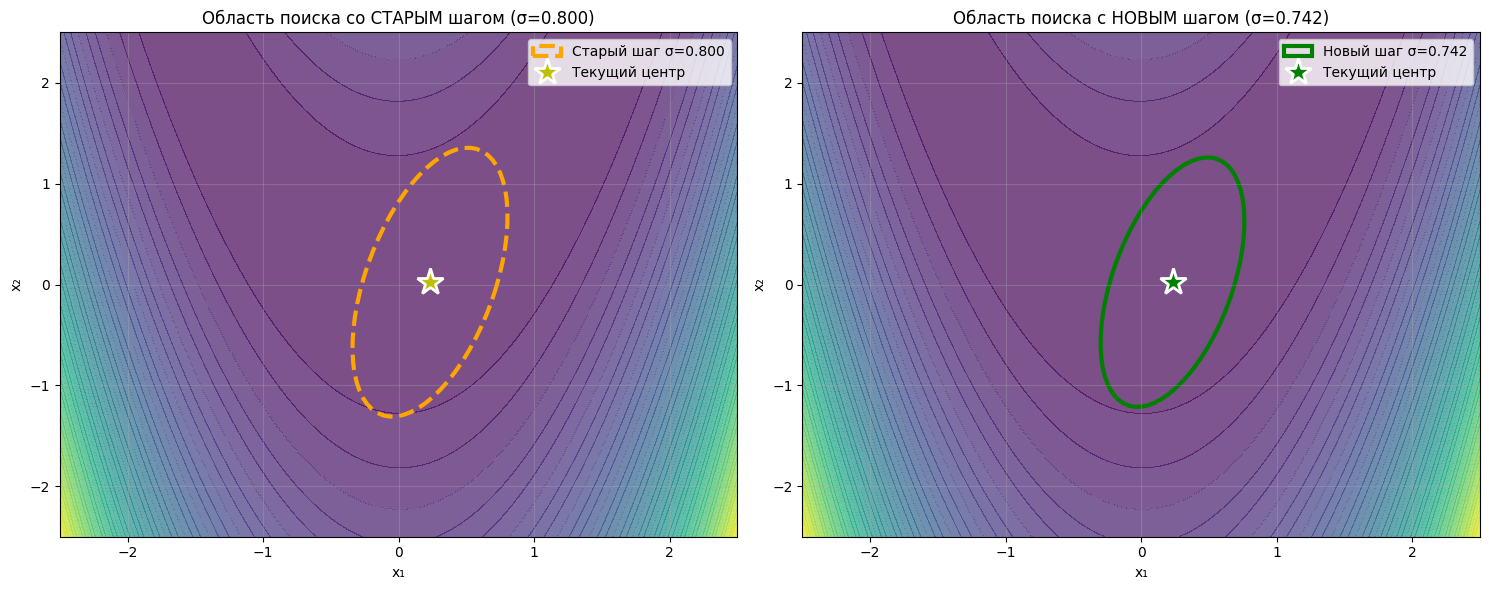

In [55]:
# Вычисляем длину эволюционного пути (по формуле)
L = np.linalg.cholesky(C)
invL = np.linalg.inv(L)
step_norm = np.linalg.norm(invL @ (mean - old_mean) / sigma)

expected_norm = np.sqrt(dim) * (1 - 1/(4*dim) + 1/(21*dim**2)) # ожидаемая длина для случайного шага (по формуле)

# Адаптируем шаг
d_sigma = 1.0  # демпфирующий параметр
c_sigma = 0.3  # скорость обучения

old_sigma = sigma
if step_norm > expected_norm:
    # Движемся в согласованном направлении - увеличиваем шаг
    sigma = sigma * np.exp(c_sigma/d_sigma * (step_norm/expected_norm - 1))
    direction = "Увеличиваем шаг"
else:
    # Случайные направления - уменьшаем шаг
    sigma = sigma * np.exp(c_sigma/d_sigma * (step_norm/expected_norm - 1))
    direction = "Уменьшаем шаг"


print(f"Старый шаг σ: {old_sigma:.4f}")
print(f"Норма смещения в преобразованном пространстве: {step_norm:.4f}")
print(f"Ожидаемая норма для случайного шага: {expected_norm:.4f}")
print(f"Сравнение: step_norm {'>' if step_norm > expected_norm else '<'} expected_norm")
print(f"{direction}")
print(f"Новый шаг σ: {sigma:.4f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# левый график - старый шаг
ax1.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
ax1.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

#эллипс со старым шагом
eigvals_show, eigvecs_show = np.linalg.eigh(C)
idx_show = np.argsort(eigvals_show)[::-1]
angle_show = np.degrees(np.arctan2(eigvecs_show[1, idx_show[0]], eigvecs_show[0, idx_show[0]]))
ellipse_old_step = Ellipse(xy=mean,
                          width=old_sigma * np.sqrt(5.991 * eigvals_show[idx_show[0]]),
                          height=old_sigma * np.sqrt(5.991 * eigvals_show[idx_show[1]]),
                          angle=angle_show,
                          edgecolor='orange', facecolor='none', linewidth=3, linestyle='--',
                          label=f'Старый шаг σ={old_sigma:.3f}')
ax1.add_patch(ellipse_old_step)

ax1.plot(mean[0], mean[1], 'y*', markersize=20, label='Текущий центр', markeredgecolor='white', markeredgewidth=2)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title(f'Область поиска со СТАРЫМ шагом (σ={old_sigma:.3f})')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2.5, 2.5)
ax1.set_ylim(-2.5, 2.5)

#правый график - новый шаг
ax2.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
ax2.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)

#эллипс с новым шагом
ellipse_new_step = Ellipse(xy=mean,
                          width=sigma * np.sqrt(5.991 * eigvals_show[idx_show[0]]),
                          height=sigma * np.sqrt(5.991 * eigvals_show[idx_show[1]]),
                          angle=angle_show,
                          edgecolor='green', facecolor='none', linewidth=3, linestyle='-',
                          label=f'Новый шаг σ={sigma:.3f}')
ax2.add_patch(ellipse_new_step)

ax2.plot(mean[0], mean[1], 'g*', markersize=20, label='Текущий центр', markeredgecolor='white', markeredgewidth=2)
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title(f'Область поиска с НОВЫМ шагом (σ={sigma:.3f})')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2.5, 2.5)
ax2.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()

Таким образом, после каждой итерации CMA-ES мы смотрим, насколько уверенно движемся. Если мы некоторое время уверенно двигались в одном направлении, то есть смысл увеличить шаг (есть уверенность, что мы движемся в нужную сторону). Если же мы топчемся на месте, необходимо уменьшить шаг (сделать его точнее).

Одна полная итерация CMA-ES:
шаг 1: Задание пространства
 Начальный центр: (0.000, -1.000)
 Начальный шаг σ: 0.800
 Начальная форма: эллиптическая
шаг 2: Генерация точек (сэмплинг)
Сгенерировано 15 точек
шаг 3: Оценка и отбор лучших точек
Лучшая точка: (0.466, 0.400) со значением функции 1.278
шаг 4: Адаптация ковариационной матрицы и глобального шага
 Новый центр: (0.231, 0.023)
 Новая форма: эллипс с соотношением осей 2.807
 Новый шаг σ: 0.742 (Уменьшаем шаг)
Что произошло за одну итерацию:
Центр сместился из (0.000, -1.000) в (0.231, 0.023)
Шаг уменьшился с 0.800 до 0.742
Форма изменилась


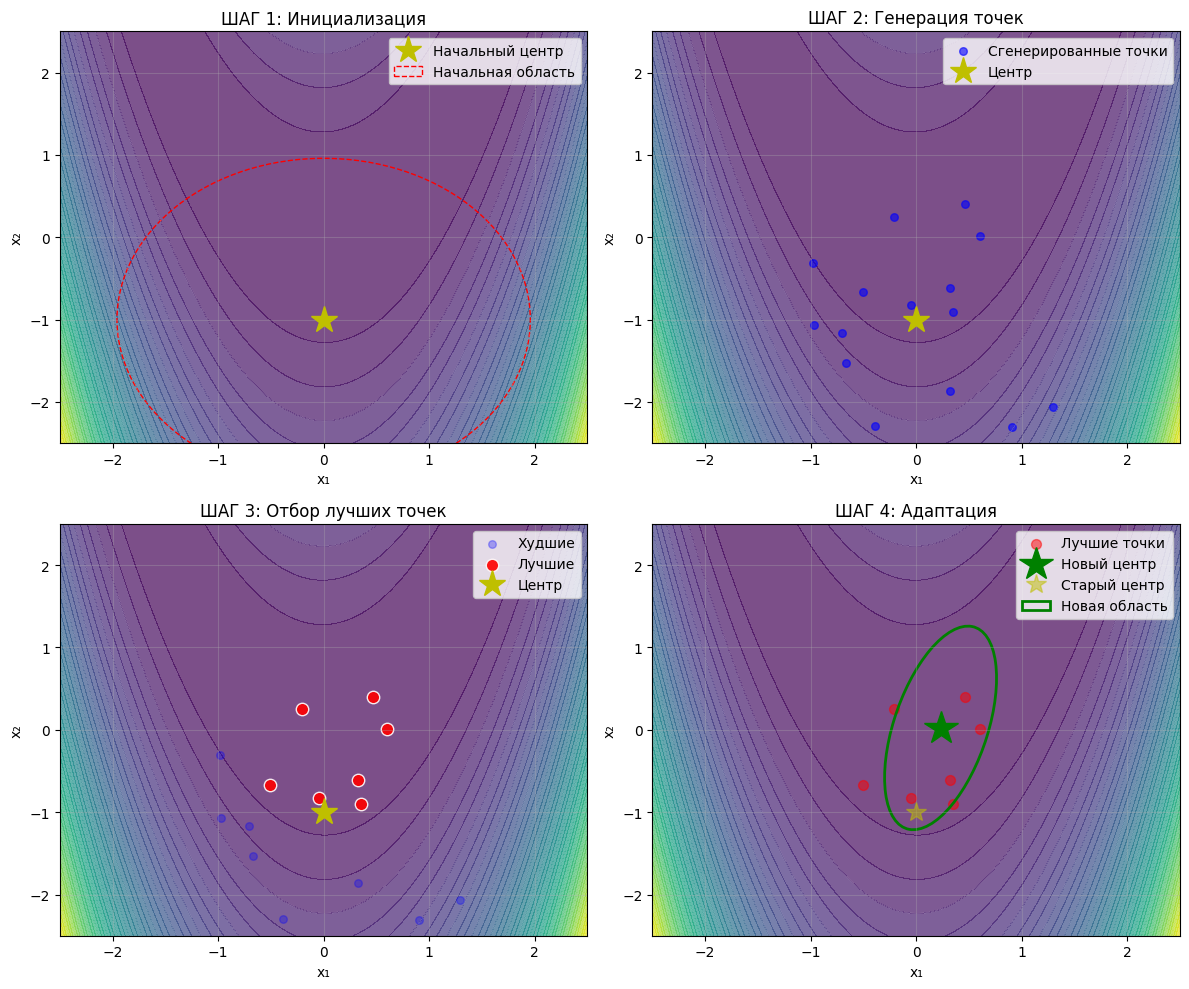

In [56]:
# собираем всё вместе для одной полной итерации
print("Одна полная итерация CMA-ES:")

print("шаг 1: Задание пространства")
print(f" Начальный центр: ({old_mean[0]:.3f}, {old_mean[1]:.3f})")
print(f" Начальный шаг σ: {old_sigma:.3f}")
print(f" Начальная форма: {'круглая' if np.allclose(C, np.eye(dim)) else 'эллиптическая'}")

print("шаг 2: Генерация точек (сэмплинг)")
print(f"Сгенерировано {popsize} точек")

print("шаг 3: Оценка и отбор лучших точек")
print(f"Лучшая точка: ({best_points[0, 0]:.3f}, {best_points[0, 1]:.3f}) со значением функции {best_fitness[0]:.3f}")

print("шаг 4: Адаптация ковариационной матрицы и глобального шага")
print(f" Новый центр: ({mean[0]:.3f}, {mean[1]:.3f})")
print(f" Новая форма: эллипс с соотношением осей {np.sqrt(eigvals[1]/eigvals[0]):.3f}")
print(f" Новый шаг σ: {sigma:.3f} ({direction})")

print("Что произошло за одну итерацию:")
print(f"Центр сместился из ({old_mean[0]:.3f}, {old_mean[1]:.3f}) в ({mean[0]:.3f}, {mean[1]:.3f})")
print(f"Шаг {'увеличился' if sigma > old_sigma else 'уменьшился'} с {old_sigma:.3f} до {sigma:.3f}")
print(f"Форма изменилась")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

steps = [
    "ШАГ 1: Инициализация",
    "ШАГ 2: Генерация точек",
    "ШАГ 3: Отбор лучших точек",
    "ШАГ 4: Адаптация"
]

for i, ax in enumerate(axes):
    ax.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
    ax.contour(X, Y, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)
    ax.set_title(steps[i])
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)

    if i == 0:  # инициализация
        ax.plot(old_mean[0], old_mean[1], 'y*', markersize=20, label='Начальный центр')
        circle0 = plt.Circle(old_mean, old_sigma * np.sqrt(5.991), fill=False, color='red', linestyle='--', label='Начальная область')
        ax.add_patch(circle0)
        ax.legend()

    elif i == 1:  #генерация
        ax.scatter(points[:, 0], points[:, 1], c='blue', s=30, alpha=0.6, label='Сгенерированные точки')
        ax.plot(old_mean[0], old_mean[1], 'y*', markersize=20, label='Центр')
        ax.legend()

    elif i == 2:  #отбор
        ax.scatter(points[worst_indices, 0], points[worst_indices, 1], c='blue', s=30, alpha=0.3, label='Худшие')
        ax.scatter(best_points[:, 0], best_points[:, 1], c='red', s=80, alpha=0.9, edgecolors='white', label='Лучшие')
        ax.plot(old_mean[0], old_mean[1], 'y*', markersize=20, label='Центр')
        ax.legend()

    else:  #результат адаптации
        ax.scatter(best_points[:, 0], best_points[:, 1], c='red', s=50, alpha=0.5, label='Лучшие точки')
        ax.plot(mean[0], mean[1], 'g*', markersize=25, label='Новый центр')
        ax.plot(old_mean[0], old_mean[1], 'y*', markersize=15, alpha=0.5, label='Старый центр')

        eigvals_final, eigvecs_final = np.linalg.eigh(C)
        idx_final = np.argsort(eigvals_final)[::-1]
        angle_final = np.degrees(np.arctan2(eigvecs_final[1, idx_final[0]], eigvecs_final[0, idx_final[0]]))
        ellipse_final = Ellipse(xy=mean,
                              width=sigma * np.sqrt(5.991 * eigvals_final[idx_final[0]]),
                              height=sigma * np.sqrt(5.991 * eigvals_final[idx_final[1]]),
                              angle=angle_final,
                              edgecolor='green', facecolor='none', linewidth=2, label='Новая область')
        ax.add_patch(ellipse_final)
        ax.legend()

plt.tight_layout()
plt.show()


Таким образом, CMA-ES помогает для нахождения глобального минимума loss-a без использования производных:  
1. Начинаем с одной точки и круговой области поиска
2. Генерируем точки
3. Смотрим, какие точки пришли в самое глубокое место ладшафта (находим минимумы функции)
4. Перемещаем центр к лучшим точкам
5. Изменяем форму поиска (эллипс) под ландшафт
6. Увеличиваем или уменьшаем шаг в зависимости от успеха
7. Повторяем, пока не найдем глобальный минимум

Итерация 1
  Новый центр поиска: (-0.1150, -0.7842)
  Значение функции в центре: 20.320958
  Текущий шаг sigma: 0.6663
  Расстояние до глобального минимума (1,1): 2.1040
Итерация 2
  Новый центр поиска: (0.4703, 0.0887)
  Значение функции в центре: 0.806609
  Текущий шаг sigma: 1.1217
  Расстояние до глобального минимума (1,1): 1.0541
Итерация 3
  Новый центр поиска: (0.7777, 0.6838)
  Значение функции в центре: 0.236521
  Текущий шаг sigma: 1.5452
  Расстояние до глобального минимума (1,1): 0.3865
Итерация 4
  Новый центр поиска: (0.6568, 0.4558)
  Значение функции в центре: 0.135768
  Текущий шаг sigma: 1.3116
  Расстояние до глобального минимума (1,1): 0.6434
Итерация 5
  Новый центр поиска: (0.5843, 0.5732)
  Значение функции в центре: 1.784265
  Текущий шаг sigma: 1.0388
  Расстояние до глобального минимума (1,1): 0.5958
Итерация 6
  Новый центр поиска: (0.6001, 0.4736)
  Значение функции в центре: 0.545974
  Текущий шаг sigma: 0.7452
  Расстояние до глобального минимума (1,1): 0.

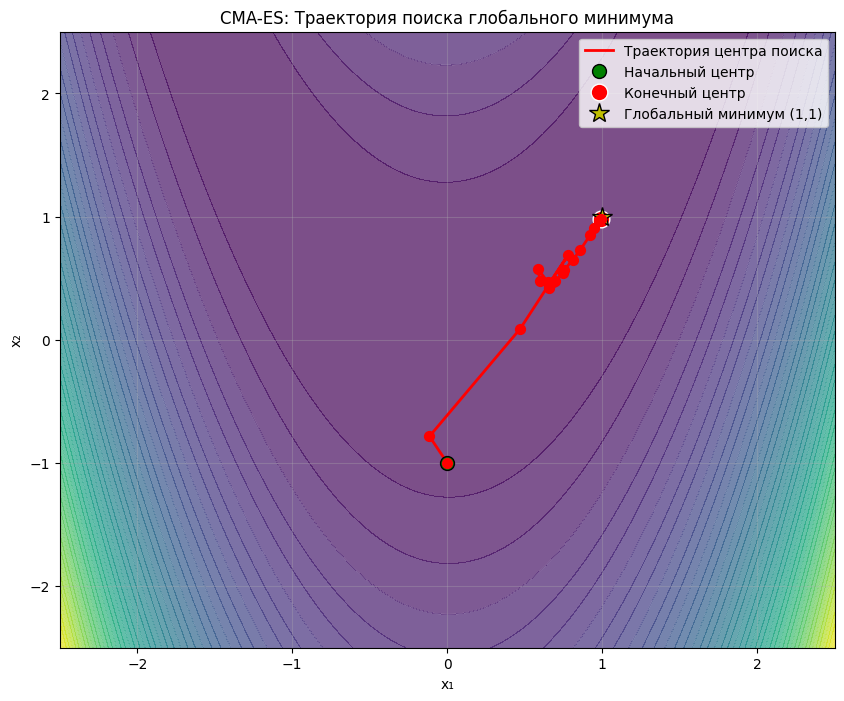

Финальный результат:
  Найденный минимум в точке: (0.988588, 0.978184)
  Значение функции: 0.0001533771
  Расстояние до истинного глобального минимума (1,1): 0.024621


In [59]:
from matplotlib.patches import Ellipse
from scipy.linalg import eigh

# сохраняем параметры алгоритма из предыдущих ячеек
sigma = 0.8
dim = 2
C = np.eye(dim)
mean = np.array([0, -1])  # начальная точка (центр поиска)

popsize = 15
mu = 7

# Веса
weights = np.log((popsize + 0.5) / 2) - np.log(np.arange(1, mu + 1))
weights = weights / np.sum(weights)


mu_eff = 1 / np.sum(weights**2)
c_c = (4 + mu_eff/dim) / (dim + 4 + 2*mu_eff/dim)
c_1 = 2 / ((dim + 1.3)**2 + mu_eff)
c_mu = min(1 - c_1, 2 * (mu_eff - 2 + 1/mu_eff) / ((dim + 2)**2 + mu_eff))
p_s = np.zeros(dim)
p_c = np.zeros(dim)

d_s = 1 + 2 * max(0, np.sqrt((mu_eff - 1) / (dim + 1)) - 1) + c_c
chi_N = np.sqrt(dim) * (1 - 1/(4*dim) + 1/(21*dim**2))

means_history = [mean.copy()]

for iteration in range(20):
    print(f"Итерация {iteration + 1}")

    # 1.Сэмплирование
    y_k = np.random.multivariate_normal(np.zeros(dim), C, size=popsize)
    points = mean + sigma * y_k

    # 2.Оценка и отбор лучших точек
    fitness = np.array([objective_function(p[0], p[1]) for p in points])
    sorted_indices = np.argsort(fitness)
    best_indices = sorted_indices[:mu]
    best_points = points[best_indices]
    best_y = y_k[best_indices]

    # 3.Обновление среднего (центр поиска)
    mean_new = np.sum(weights[:, np.newaxis] * best_points, axis=0)

    # 4.Обновление эволюционных путей и ковариационной матрицы
    mean_shift = (mean_new - mean) / sigma

    p_s = (1 - c_c) * p_s + np.sqrt(c_c * (2 - c_c) * mu_eff) * mean_shift

    norm_p_s = np.linalg.norm(p_s)
    expected_norm = np.sqrt(1 - (1 - c_c)**(2*(iteration+1))) * chi_N
    h_s = 1 if norm_p_s / expected_norm < (1.4 + 2/(dim+1)) else 0

    p_c = (1 - c_c) * p_c + h_s * np.sqrt(c_c * (2 - c_c) * mu_eff) * mean_shift

    w_io = weights * (1 if h_s else 0)
    if np.sum(w_io) > 0:
        w_io = w_io / np.sum(w_io)
    else:
        w_io = np.ones(mu) / mu

    rank_one = c_1 * (np.outer(p_c, p_c) + (1 - h_s) * c_c * (2 - c_c) * C)
    rank_mu = c_mu * np.sum([w_io[i] * np.outer(best_y[i], best_y[i]) for i in range(mu)], axis=0)

    C = (1 - c_1 - c_mu) * C + rank_one + rank_mu
    C = (C + C.T) / 2
    sigma = sigma * np.exp((c_c / d_s) * (norm_p_s / chi_N - 1))

    mean = mean_new
    means_history.append(mean.copy())

    print(f"  Новый центр поиска: ({mean[0]:.4f}, {mean[1]:.4f})")
    print(f"  Значение функции в центре: {objective_function(mean[0], mean[1]):.6f}")
    print(f"  Текущий шаг sigma: {sigma:.4f}")
    dist_to_global = np.linalg.norm(mean - np.array([1, 1]))
    print(f"  Расстояние до глобального минимума (1,1): {dist_to_global:.4f}")



plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
plt.contour(X, Y, Z, levels=20,colors='white', alpha=0.3, linewidths=0.5)

means_history = np.array(means_history)
plt.plot(means_history[:, 0], means_history[:, 1], 'r-', linewidth=2, label='Траектория центра поиска')
plt.scatter(means_history[:, 0], means_history[:, 1], c='red', s=50, zorder=5)

plt.plot(means_history[0, 0], means_history[0, 1], 'go', markersize=10, label='Начальный центр', markeredgecolor='black')
plt.plot(means_history[-1, 0], means_history[-1, 1], 'ro', markersize=12, label='Конечный центр', markeredgecolor='white')

plt.plot(1, 1, 'y*', markersize=15, label='Глобальный минимум (1,1)', markeredgecolor='black')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('CMA-ES: Траектория поиска глобального минимума')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.show()

print(f"Финальный результат:")
print(f"  Найденный минимум в точке: ({mean[0]:.6f}, {mean[1]:.6f})")
print(f"  Значение функции: {objective_function(mean[0], mean[1]):.10f}")
print(f"  Расстояние до истинного глобального минимума (1,1): {np.linalg.norm(mean - np.array([1, 1])):.6f}")

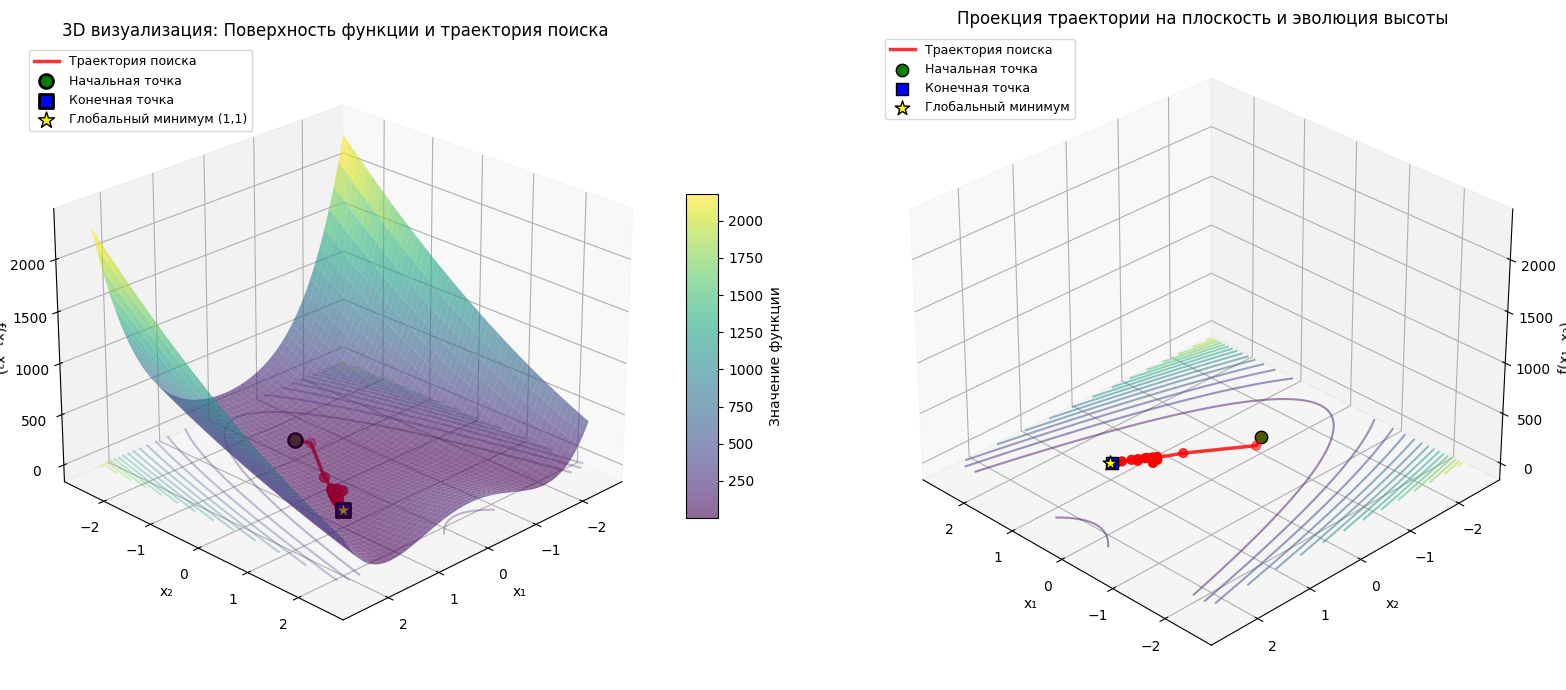

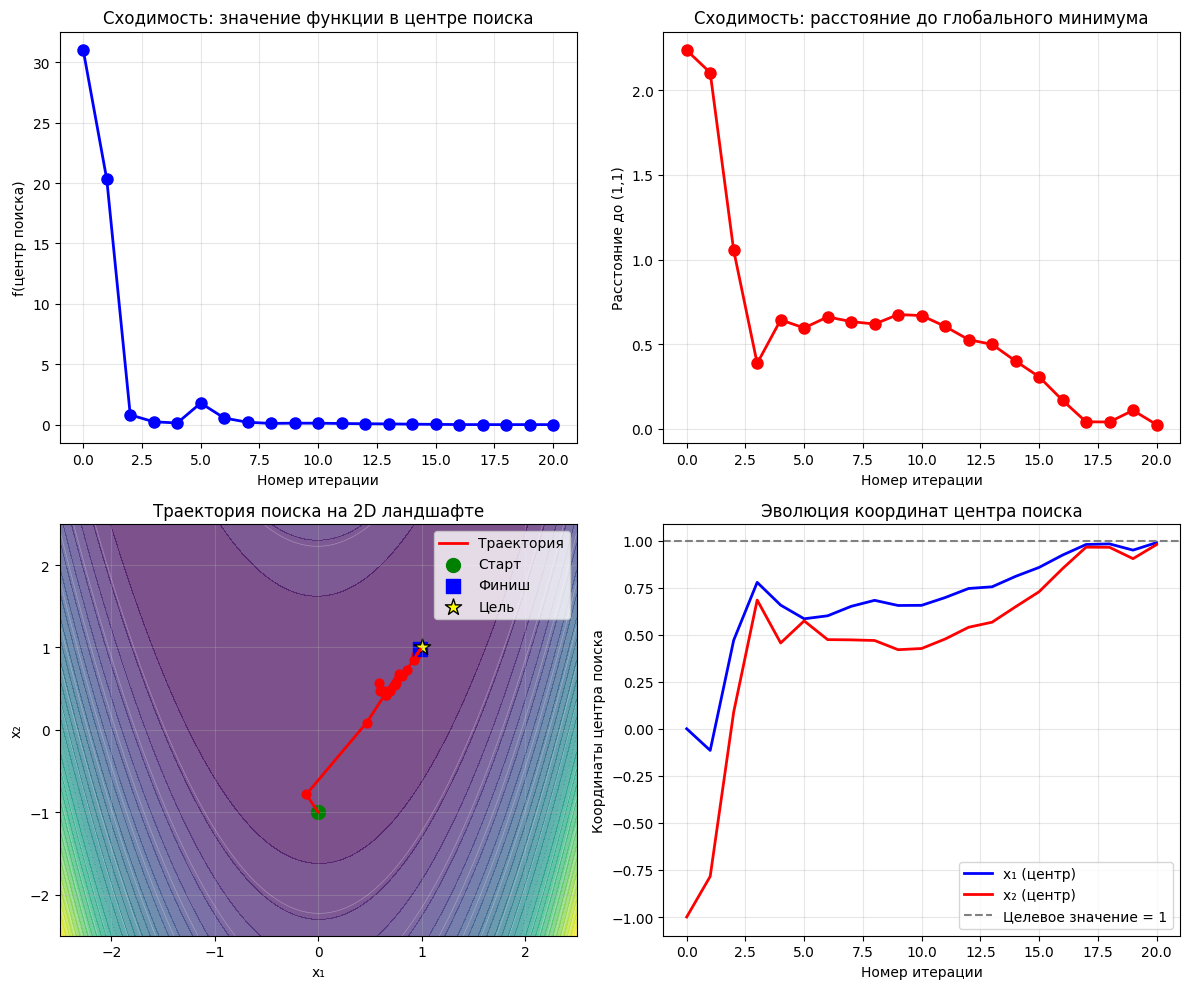






Результаты по итерациям:
 Итерация  |      Центр (x₁, x₂)       |   f(центр)   | Расстояние до (1,1) 
---------------------------------------------------------------------------
    0      | ( 0.0000, -1.0000) |  31.000000 |           2.236068
    1      | (-0.1150, -0.7842) |  20.320958 |           2.103979
    2      | ( 0.4703,  0.0887) |   0.806609 |           1.054061
    3      | ( 0.7777,  0.6838) |   0.236521 |           0.386532
    4      | ( 0.6568,  0.4558) |   0.135768 |           0.643396
    5      | ( 0.5843,  0.5732) |   1.784265 |           0.595822
    6      | ( 0.6001,  0.4736) |   0.545974 |           0.661090
    7      | ( 0.6503,  0.4722) |   0.195358 |           0.633142
    8      | ( 0.6823,  0.4689) |   0.101315 |           0.618906
    9      | ( 0.6549,  0.4200) |   0.121449 |           0.674890
    10     | ( 0.6557,  0.4264) |   0.118904 |           0.668968
    11     | ( 0.6969,  0.4766) |   0.094309 |           0.604803
    12     | ( 0.7452,  0

In [60]:

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(16, 7))

# Первый 3D-график: поверхность + траектория
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, linewidth=0, antialiased=True)
contour = ax1.contour(X, Y, Z, zdir='z', offset=0, cmap='viridis', alpha=0.3, levels=15)
means_trajectory = np.array(means_history)
trajectory_z = np.array([objective_function(p[0], p[1]) for p in means_trajectory])

# Рисуем траекторию
ax1.plot(means_trajectory[:, 0], means_trajectory[:, 1], trajectory_z,
         'r-', linewidth=2.5, label='Траектория поиска', alpha=0.8)

# Рисуем точки траектории
ax1.scatter(means_trajectory[:, 0], means_trajectory[:, 1], trajectory_z,
            c='red', s=50, zorder=10)

ax1.scatter(means_trajectory[0, 0], means_trajectory[0, 1], trajectory_z[0],
            c='green', s=100, marker='o', label='Начальная точка', edgecolors='black', linewidth=2)
ax1.scatter(means_trajectory[-1, 0], means_trajectory[-1, 1], trajectory_z[-1],
            c='blue', s=100, marker='s', label='Конечная точка', edgecolors='black', linewidth=2)

ax1.scatter(1, 1, objective_function(1, 1),
            c='yellow', s=150, marker='*', label='Глобальный минимум (1,1)',
            edgecolors='black', linewidth=1)

ax1.set_xlabel('x₁', fontsize=10)
ax1.set_ylabel('x₂', fontsize=10)
ax1.set_zlabel('f(x₁, x₂)', fontsize=10)
ax1.set_title('3D визуализация: Поверхность функции и траектория поиска', fontsize=12)

fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Значение функции')

ax1.view_init(elev=25, azim=45)
ax1.legend(loc='upper left', fontsize=9)


ax2 = fig.add_subplot(1, 2, 2, projection='3d')
contour2 = ax2.contour(X, Y, Z, zdir='z', offset=0, cmap='viridis', alpha=0.5, levels=20)

ax2.plot(means_trajectory[:, 0], means_trajectory[:, 1], 0,
         'r-', linewidth=2.5, alpha=0.8, label='Траектория поиска')

ax2.scatter(means_trajectory[:, 0], means_trajectory[:, 1], 0,
            c='red', s=40, zorder=10)

ax2.scatter(means_trajectory[0, 0], means_trajectory[0, 1], 0,
            c='green', s=80, marker='o', label='Начальная точка', edgecolors='black')
ax2.scatter(means_trajectory[-1, 0], means_trajectory[-1, 1], 0,
            c='blue', s=80, marker='s', label='Конечная точка', edgecolors='black')

ax2.scatter(1, 1, 0, c='yellow', s=120, marker='*', label='Глобальный минимум', edgecolors='black')


for i, point in enumerate(means_trajectory):
    ax2.plot([point[0], point[0]], [point[1], point[1]], [0, trajectory_z[i]],
             'gray', linewidth=0.5, alpha=0.3)

ax2.set_xlabel('x₁', fontsize=10)
ax2.set_ylabel('x₂', fontsize=10)
ax2.set_zlabel('f(x₁, x₂)', fontsize=10)
ax2.set_title('Проекция траектории на плоскость и эволюция высоты', fontsize=12)
ax2.view_init(elev=30, azim=135)
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Значение функции в центре поиска по итерациям
ax = axes[0, 0]
iterations = np.arange(len(trajectory_z))
ax.plot(iterations, trajectory_z, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('f(центр поиска)')
ax.set_title('Сходимость: значение функции в центре поиска')
ax.grid(True, alpha=0.3)

# График 2: Расстояние до глобального минимума по итерациям
ax = axes[0, 1]
distances = [np.linalg.norm(p - np.array([1, 1])) for p in means_trajectory]
ax.plot(iterations, distances, 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Номер итерации')
ax.set_ylabel('Расстояние до (1,1)')
ax.set_title('Сходимость: расстояние до глобального минимума')
ax.grid(True, alpha=0.3)

# График 3: Траектория на плоскости
ax = axes[1, 0]
contour_plot = ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.7)
ax.contour(X, Y, Z, levels=15, colors='white', alpha=0.3, linewidths=0.5)
ax.plot(means_trajectory[:, 0], means_trajectory[:, 1], 'r-', linewidth=2, label='Траектория')
ax.scatter(means_trajectory[:, 0], means_trajectory[:, 1], c='red', s=40)
ax.scatter(means_trajectory[0, 0], means_trajectory[0, 1], c='green', s=100, marker='o', label='Старт')
ax.scatter(means_trajectory[-1, 0], means_trajectory[-1, 1], c='blue', s=100, marker='s', label='Финиш')
ax.scatter(1, 1, c='yellow', s=150, marker='*', label='Цель', edgecolors='black')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Траектория поиска на 2D ландшафте')
ax.legend()
ax.grid(True, alpha=0.3)

# График 4: Эволюция параметров алгоритма
ax = axes[1, 1]

ax.plot(iterations, means_trajectory[:, 0], 'b-', label='x₁ (центр)', linewidth=2)
ax.plot(iterations, means_trajectory[:, 1], 'r-', label='x₂ (центр)', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', label='Целевое значение = 1')
ax.set_xlabel('Номер итерации')
ax.set_ylabel('Координаты центра поиска')
ax.set_title('Эволюция координат центра поиска')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" * 4)
print("Результаты по итерациям:")

print(f"{'Итерация':^10} | {'Центр (x₁, x₂)':^25} | {'f(центр)':^12} | {'Расстояние до (1,1)':^20}")
print("-" * 75)
for i, (point, z_val, dist) in enumerate(zip(means_trajectory, trajectory_z, distances)):
    print(f"{i:^10} | ({point[0]:7.4f}, {point[1]:7.4f}) | {z_val:10.6f} | {dist:18.6f}")
print("=" * 75)